## Libraries + Import

In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns

from pathlib import Path
import os
import pandas as pd
import random
from PIL import Image
from concurrent.futures import ThreadPoolExecutor
from collections import Counter
import numpy as np
import cv2
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset

import torchvision.transforms as T
from torchvision.datasets import ImageFolder
from torchvision.models import resnet18, ResNet18_Weights

import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from lightning.pytorch.loggers import TensorBoardLogger
from torchmetrics.classification import BinaryAccuracy, BinaryF1Score, BinaryAUROC
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import BinaryClassifierOutputTarget

from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

In [2]:
PROJECT_ROOT = Path.cwd().parent

DATASET_PATH = PROJECT_ROOT / "datasets" / "faceforensics++"

REAL_DIR = DATASET_PATH / "original"

CLASSES = [
    "Original",
    "Deepfakes",
    "Face2Face",
    "FaceShifter",
    "FaceSwap",
    "NeuralTextures",
    #"DeepFakeDetection"
]

print(DATASET_PATH)

c:\Users\tomma\DeepfakeSII\datasets\faceforensics++


In [3]:
import pandas as pd
from pathlib import Path

csv_dir = DATASET_PATH / "csv"

for csv_file in sorted(csv_dir.glob("*.csv")):
    print(csv_file.name)
    df = pd.read_csv(csv_file)
    display(df)

DeepFakeDetection.csv


,Unnamed: 0,File Path,Label,Frame Count,Width,Height,Codec,File Size(MB)
0,0,DeepFakeDetection/01_02__meeting_serious__YVGY...,FAKE,1044,1920,1080,h264,6.43
1,1,DeepFakeDetection/01_02__outside_talking_still...,FAKE,727,1920,1080,h264,5.05
2,2,DeepFakeDetection/01_02__talking_against_wall_...,FAKE,841,1920,1080,h264,3.31
3,3,DeepFakeDetection/01_02__walk_down_hall_angry_...,FAKE,217,1920,1080,h264,1.11
4,4,DeepFakeDetection/01_02__walking_down_indoor_h...,FAKE,773,1920,1080,h264,12.05
...,...,...,...,...,...,...,...,...
995,995,DeepFakeDetection/28_08__podium_speech_happy__...,FAKE,949,1920,1080,h264,7.26
996,996,DeepFakeDetection/28_08__talking_angry_couch__...,FAKE,1279,1920,1080,h264,15.78
997,997,DeepFakeDetection/28_16__podium_speech_happy__...,FAKE,951,1920,1080,h264,7.29
998,998,DeepFakeDetection/28_16__walking_down_street_o...,FAKE,1198,1920,1080,h264,5.06


Deepfakes.csv


,Unnamed: 0,File Path,Label,Frame Count,Width,Height,Codec,File Size(MB)
0,0,Deepfakes/000_003.mp4,FAKE,396,640,480,h264,0.85
1,1,Deepfakes/001_870.mp4,FAKE,460,1280,720,h264,2.74
2,2,Deepfakes/002_006.mp4,FAKE,693,1280,720,h264,1.98
3,3,Deepfakes/003_000.mp4,FAKE,303,640,480,h264,0.57
4,4,Deepfakes/004_982.mp4,FAKE,309,1280,720,h264,1.19
...,...,...,...,...,...,...,...,...
995,995,Deepfakes/995_233.mp4,FAKE,548,640,480,h264,0.83
996,996,Deepfakes/996_056.mp4,FAKE,312,720,480,h264,0.87
997,997,Deepfakes/997_040.mp4,FAKE,438,600,480,h264,1.05
998,998,Deepfakes/998_561.mp4,FAKE,344,1280,720,h264,1.74


Face2Face.csv


...

,Unnamed: 0,Frame Count Mean,Width Mean,Height Mean,File Size(MB) Mean
0,DeepFakeDetection,733.791,1920.000,1080.000,6.63761
1,Deepfakes,509.128,1036.348,636.718,1.90042
2,Face2Face,509.128,1030.912,636.718,1.85666
3,FaceShifter,509.128,1036.348,636.718,1.82796
4,FaceSwap,406.140,1036.348,636.718,1.56358
5,NeuralTextures,406.137,1030.912,636.718,1.45529
6,Original,509.128,1036.348,636.718,1.84677


NeuralTextures.csv


,Unnamed: 0,File Path,Label,Frame Count,Width,Height,Codec,File Size(MB)
0,0,NeuralTextures/000_003.mp4,FAKE,303,640,480,h264,0.62
1,1,NeuralTextures/001_870.mp4,FAKE,460,1280,720,h264,2.71
2,2,NeuralTextures/002_006.mp4,FAKE,310,1280,720,h264,0.91
3,3,NeuralTextures/003_000.mp4,FAKE,303,640,480,h264,0.57
4,4,NeuralTextures/004_982.mp4,FAKE,309,1280,720,h264,1.19
...,...,...,...,...,...,...,...,...
995,995,NeuralTextures/995_233.mp4,FAKE,548,640,480,h264,0.82
996,996,NeuralTextures/996_056.mp4,FAKE,312,704,480,h264,0.85
997,997,NeuralTextures/997_040.mp4,FAKE,438,576,480,h264,1.03
998,998,NeuralTextures/998_561.mp4,FAKE,344,1280,720,h264,1.69


original.csv


,Unnamed: 0,File Path,Label,Frame Count,Width,Height,Codec,File Size(MB)
0,0,original/000.mp4,REAL,396,640,480,h264,0.85
1,1,original/001.mp4,REAL,460,1280,720,h264,2.78
2,2,original/002.mp4,REAL,693,1280,720,h264,2.02
3,3,original/003.mp4,REAL,303,640,480,h264,0.58
4,4,original/004.mp4,REAL,309,1280,720,h264,1.20
...,...,...,...,...,...,...,...,...
995,995,original/995.mp4,REAL,548,640,480,h264,0.79
996,996,original/996.mp4,REAL,312,720,480,h264,0.83
997,997,original/997.mp4,REAL,438,600,480,h264,1.02
998,998,original/998.mp4,REAL,344,1280,720,h264,1.59


## EDA

### DF and Feature Engineering

In [4]:
df = pd.read_csv(DATASET_PATH / "csv" / "FF++_Metadata.csv")
df["Class"] = df["File Path"].str.split("/").str[0].replace({"original": "Original"})
df = df[df["Class"] != "DeepFakeDetection"] # exclude the "DeepFakeDetection" class
df

,Unnamed: 0,File Path,Label,Frame Count,Width,Height,Codec,File Size(MB),Class
1000,1000,Deepfakes/000_003.mp4,FAKE,396,640,480,h264,0.85,Deepfakes
1001,1001,Deepfakes/001_870.mp4,FAKE,460,1280,720,h264,2.74,Deepfakes
1002,1002,Deepfakes/002_006.mp4,FAKE,693,1280,720,h264,1.98,Deepfakes
1003,1003,Deepfakes/003_000.mp4,FAKE,303,640,480,h264,0.57,Deepfakes
1004,1004,Deepfakes/004_982.mp4,FAKE,309,1280,720,h264,1.19,Deepfakes
...,...,...,...,...,...,...,...,...,...
6995,6995,original/995.mp4,REAL,548,640,480,h264,0.79,Original
6996,6996,original/996.mp4,REAL,312,720,480,h264,0.83,Original
6997,6997,original/997.mp4,REAL,438,600,480,h264,1.02,Original
6998,6998,original/998.mp4,REAL,344,1280,720,h264,1.59,Original


In [5]:
def get_fps(video_path):
    cap = cv2.VideoCapture(str(video_path))
    fps = cap.get(cv2.CAP_PROP_FPS) # get fps here
    cap.release()
    return fps

video_paths = []

for file_path in df["File Path"]:
    video_paths.append(DATASET_PATH / file_path)

with ThreadPoolExecutor(max_workers=16) as executor:
    fps_values = list(executor.map(get_fps, video_paths))

In [ ]:
df["Resolution"] = df["Width"].astype(str) + "x" + df["Height"].astype(str)
df["Pixel Count"] = df["Width"] * df["Height"]
df["FPS"] = fps_values
df["Video"] = (df["File Path"].str.split("/").str[-1].str.replace(".mp4", "", regex=False))
df["Duration (s)"] = (df["Frame Count"] / df["FPS"])
df["is_deepfake"] = (df["Class"].str.strip().str.lower() != "original").astype(int)
df

,Unnamed: 0,File Path,Label,Frame Count,Width,Height,Codec,File Size(MB),Class,Resolution,Pixel Count,FPS,Video,Duration (s)
1000,1000,Deepfakes/000_003.mp4,FAKE,396,640,480,h264,0.85,Deepfakes,640x480,307200,25.0,000_003,15.840000
1001,1001,Deepfakes/001_870.mp4,FAKE,460,1280,720,h264,2.74,Deepfakes,1280x720,921600,25.0,001_870,18.400000
1002,1002,Deepfakes/002_006.mp4,FAKE,693,1280,720,h264,1.98,Deepfakes,1280x720,921600,30.0,002_006,23.100000
1003,1003,Deepfakes/003_000.mp4,FAKE,303,640,480,h264,0.57,Deepfakes,640x480,307200,25.0,003_000,12.120000
1004,1004,Deepfakes/004_982.mp4,FAKE,309,1280,720,h264,1.19,Deepfakes,1280x720,921600,25.0,004_982,12.360000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6995,6995,original/995.mp4,REAL,548,640,480,h264,0.79,Original,640x480,307200,30.0,995,18.266667
6996,6996,original/996.mp4,REAL,312,720,480,h264,0.83,Original,720x480,345600,25.0,996,12.480000
6997,6997,original/997.mp4,REAL,438,600,480,h264,1.02,Original,600x480,288000,25.0,997,17.520000
6998,6998,original/998.mp4,REAL,344,1280,720,h264,1.59,Original,1280x720,921600,30.0,998,11.466667


In [ ]:
blue = "#1f77b4"
red = "#d62728"

PALETTE = {c: (blue if c == "Original" else red) for c in CLASSES}
LEGEND_ELEMENTS = [Patch(facecolor=blue, label="Real"), Patch(facecolor=red, label="Fake")]

### Label Distribution

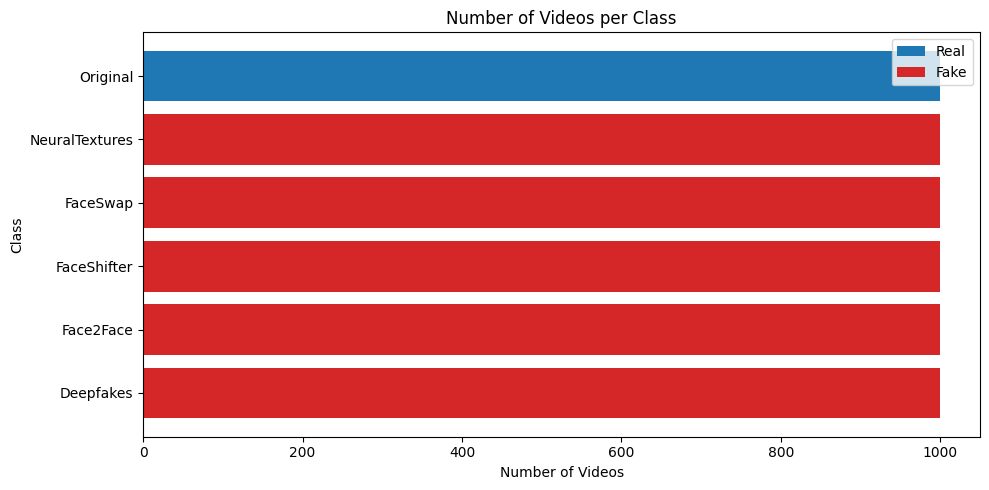

In [8]:
class_counts = df["Class"].value_counts()

plt.figure(figsize=(10, 5))
plt.barh(class_counts.index, class_counts.values, color=[PALETTE[c] for c in class_counts.index])

plt.legend(handles=LEGEND_ELEMENTS)

plt.title("Number of Videos per Class")
plt.xlabel("Number of Videos")
plt.ylabel("Class")

plt.tight_layout()
plt.show()

### Frame Count Distribution

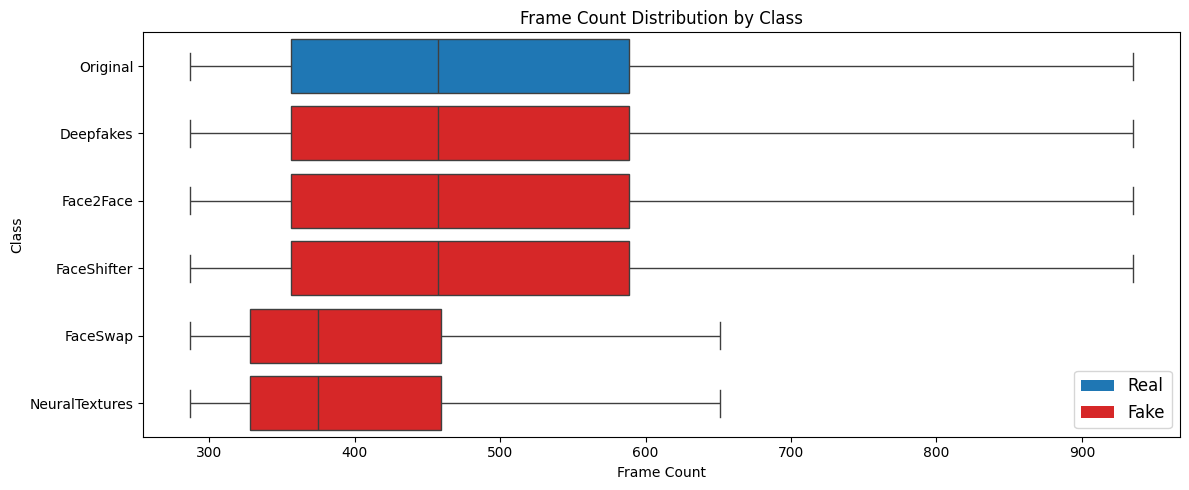

In [9]:
plt.figure(figsize=(12, 5))

sns.boxplot(data=df, x="Frame Count", y="Class", hue="Class", order=CLASSES, hue_order=CLASSES, palette=PALETTE, showfliers=False, saturation=1, legend=False)
plt.legend(handles=LEGEND_ELEMENTS, fontsize=12)

plt.title("Frame Count Distribution by Class")
plt.xlabel("Frame Count")
plt.ylabel("Class")

plt.tight_layout()
plt.show()

### File Size Distribution

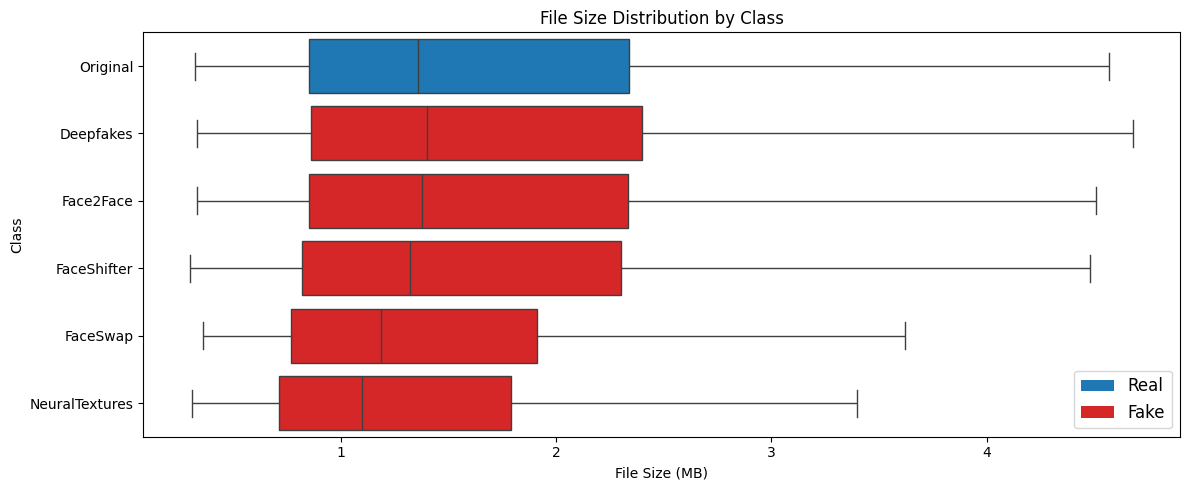

In [10]:
plt.figure(figsize=(12, 5))

sns.boxplot(data=df, x="File Size(MB)", y="Class", hue="Class", order=CLASSES, hue_order=CLASSES, palette=PALETTE, showfliers=False, saturation=1, legend=False)
plt.legend(handles=LEGEND_ELEMENTS, fontsize=12)

plt.title("File Size Distribution by Class")
plt.xlabel("File Size (MB)")
plt.ylabel("Class")

plt.tight_layout()
plt.show()

### Resolutions

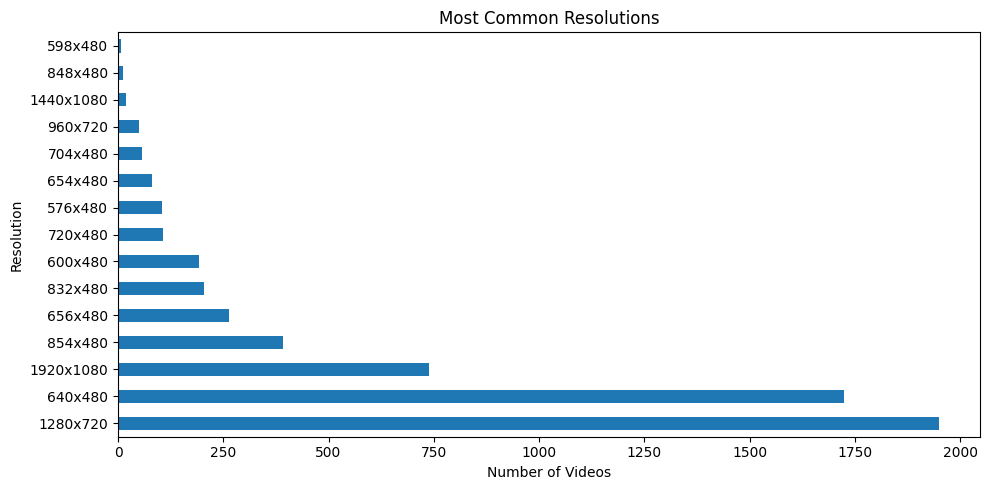

In [11]:
plt.figure(figsize=(10, 5))
df["Resolution"].value_counts().head(15).plot(kind="barh")
plt.title("Most Common Resolutions")
plt.xlabel("Number of Videos")
plt.tight_layout()
plt.show()

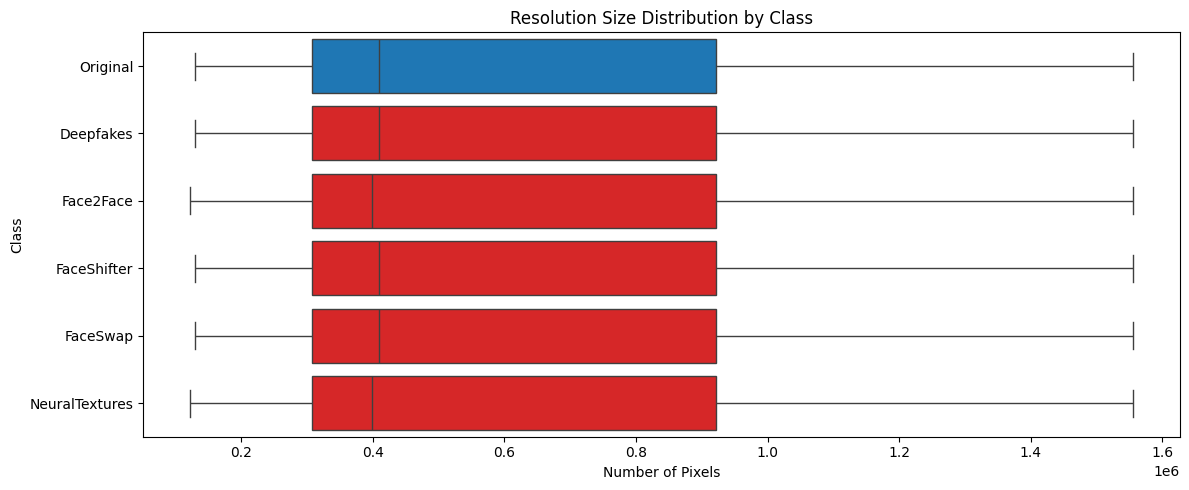

In [12]:
plt.figure(figsize=(12, 5))

sns.boxplot(data=df, x="Pixel Count", y="Class", hue="Class", order=CLASSES, hue_order=CLASSES, palette=PALETTE, showfliers=False, saturation=1, legend=False)

plt.title("Resolution Size Distribution by Class")
plt.xlabel("Number of Pixels")
plt.ylabel("Class")

plt.tight_layout()
plt.show()

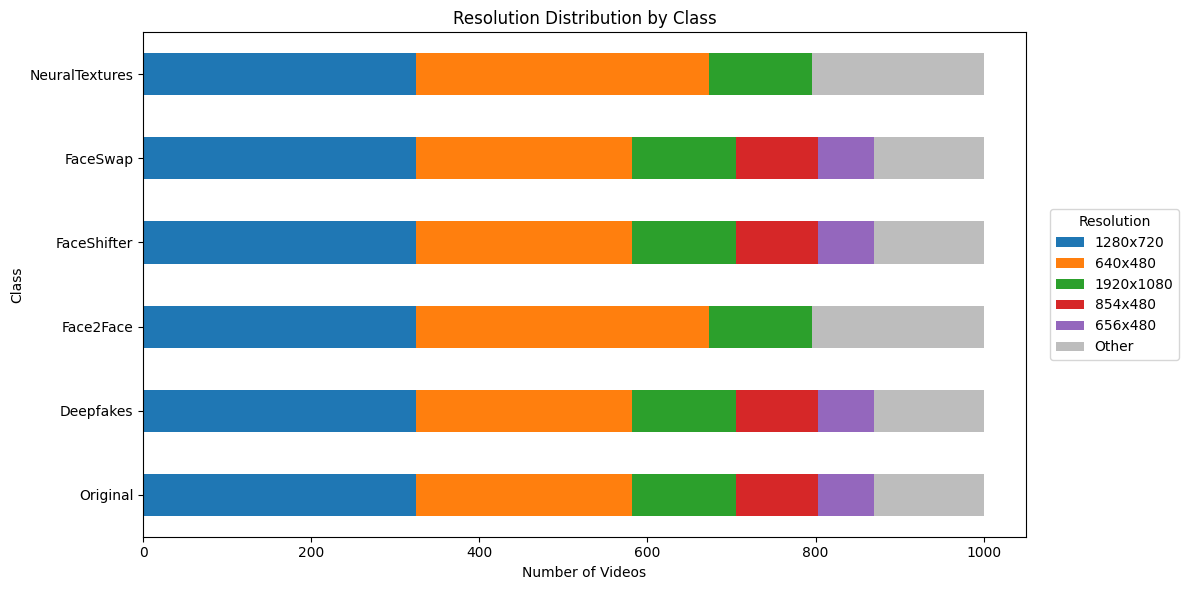

In [13]:
top_resolutions = df["Resolution"].value_counts().head(5).index.tolist() # select top 5 most frequent resolutions

df_plot = df.copy()
df_plot["Resolution Group"] = df_plot["Resolution"].apply(lambda x: x if x in top_resolutions else "Other") # group all other res as other
resolution_counts = pd.crosstab(df_plot["Class"], df_plot["Resolution Group"]) # count

resolution_counts = resolution_counts.loc[CLASSES]
column_order = top_resolutions + ["Other"] # column order: top 5 res first, then other
resolution_counts = resolution_counts[column_order] # reoder columns

colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#bdbdbd"]

ax = resolution_counts.plot(kind="barh", stacked=True, figsize=(12, 6), color=colors) # horiontal bar plot
ax.legend(title="Resolution", bbox_to_anchor=(1.02, 0.5), loc="center left")

plt.title("Resolution Distribution by Class")
plt.xlabel("Number of Videos")
plt.ylabel("Class")
plt.tight_layout()
plt.show()

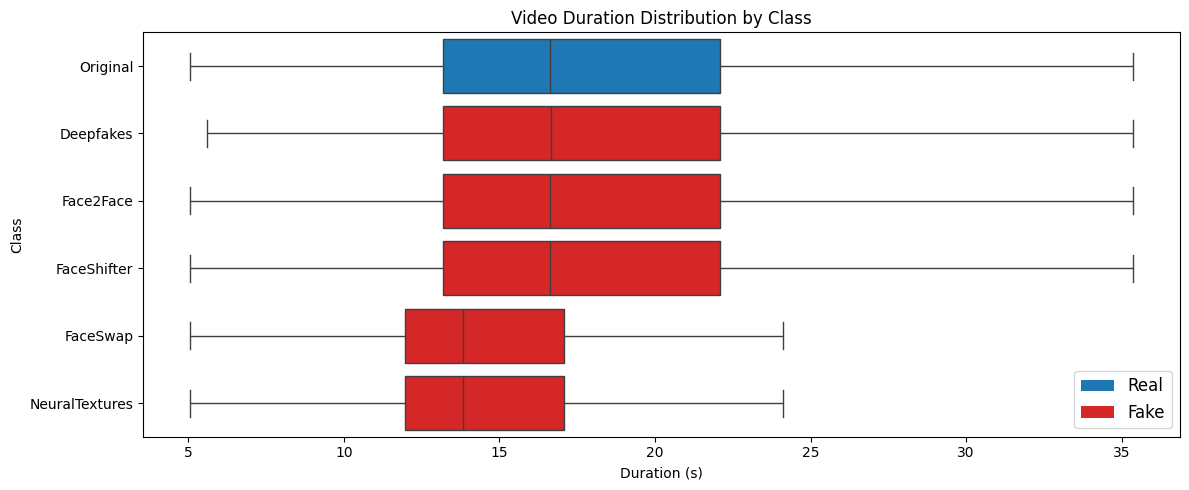

In [93]:
plt.figure(figsize=(12, 5))

sns.boxplot(data=df, x="Duration (s)", y="Class", hue="Class", order=CLASSES, hue_order=CLASSES, palette=PALETTE, showfliers=False, saturation=1, legend=False)
plt.legend(handles=LEGEND_ELEMENTS, fontsize=12)
plt.title("Video Duration Distribution by Class")

plt.xlabel("Duration (s)")
plt.ylabel("Class")
plt.tight_layout()
plt.show()

### FPS Distribution

In [14]:
df["FPS"].value_counts().sort_index()

FPS
15.0      24
18.0       6
24.0     150
25.0    2874
29.0      12
30.0    2880
50.0      12
60.0      42
Name: count, dtype: int64

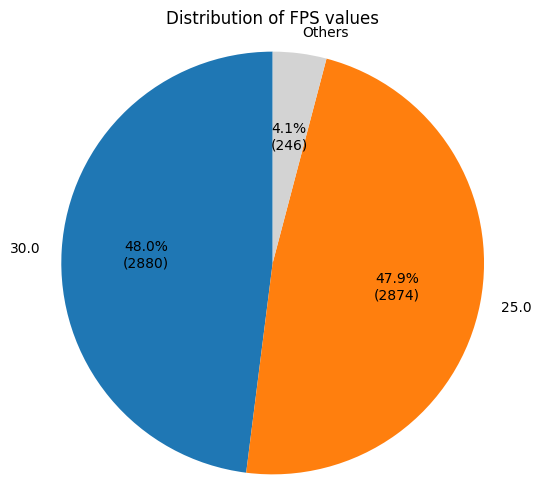

In [19]:
fps_counts = df["FPS"].value_counts()

top_2 = fps_counts.head(2)
others = fps_counts.iloc[2:].sum()

fps_pie = top_2.copy()
fps_pie.loc["Others"] = others

colors = ["tab:blue", "tab:orange", "lightgray"]

def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        count = int(round(pct * total / 100.0))
        return f"{pct:.1f}%\n({count})"
    return my_autopct

plt.figure(figsize=(6, 6))
plt.pie(fps_pie, labels=fps_pie.index, autopct=make_autopct(fps_pie), startangle=90, colors=colors)
plt.title("Distribution of FPS values")
plt.axis("equal")
plt.show()

In [7]:
(2880+2874)/6000

0.959

### Correlation between features

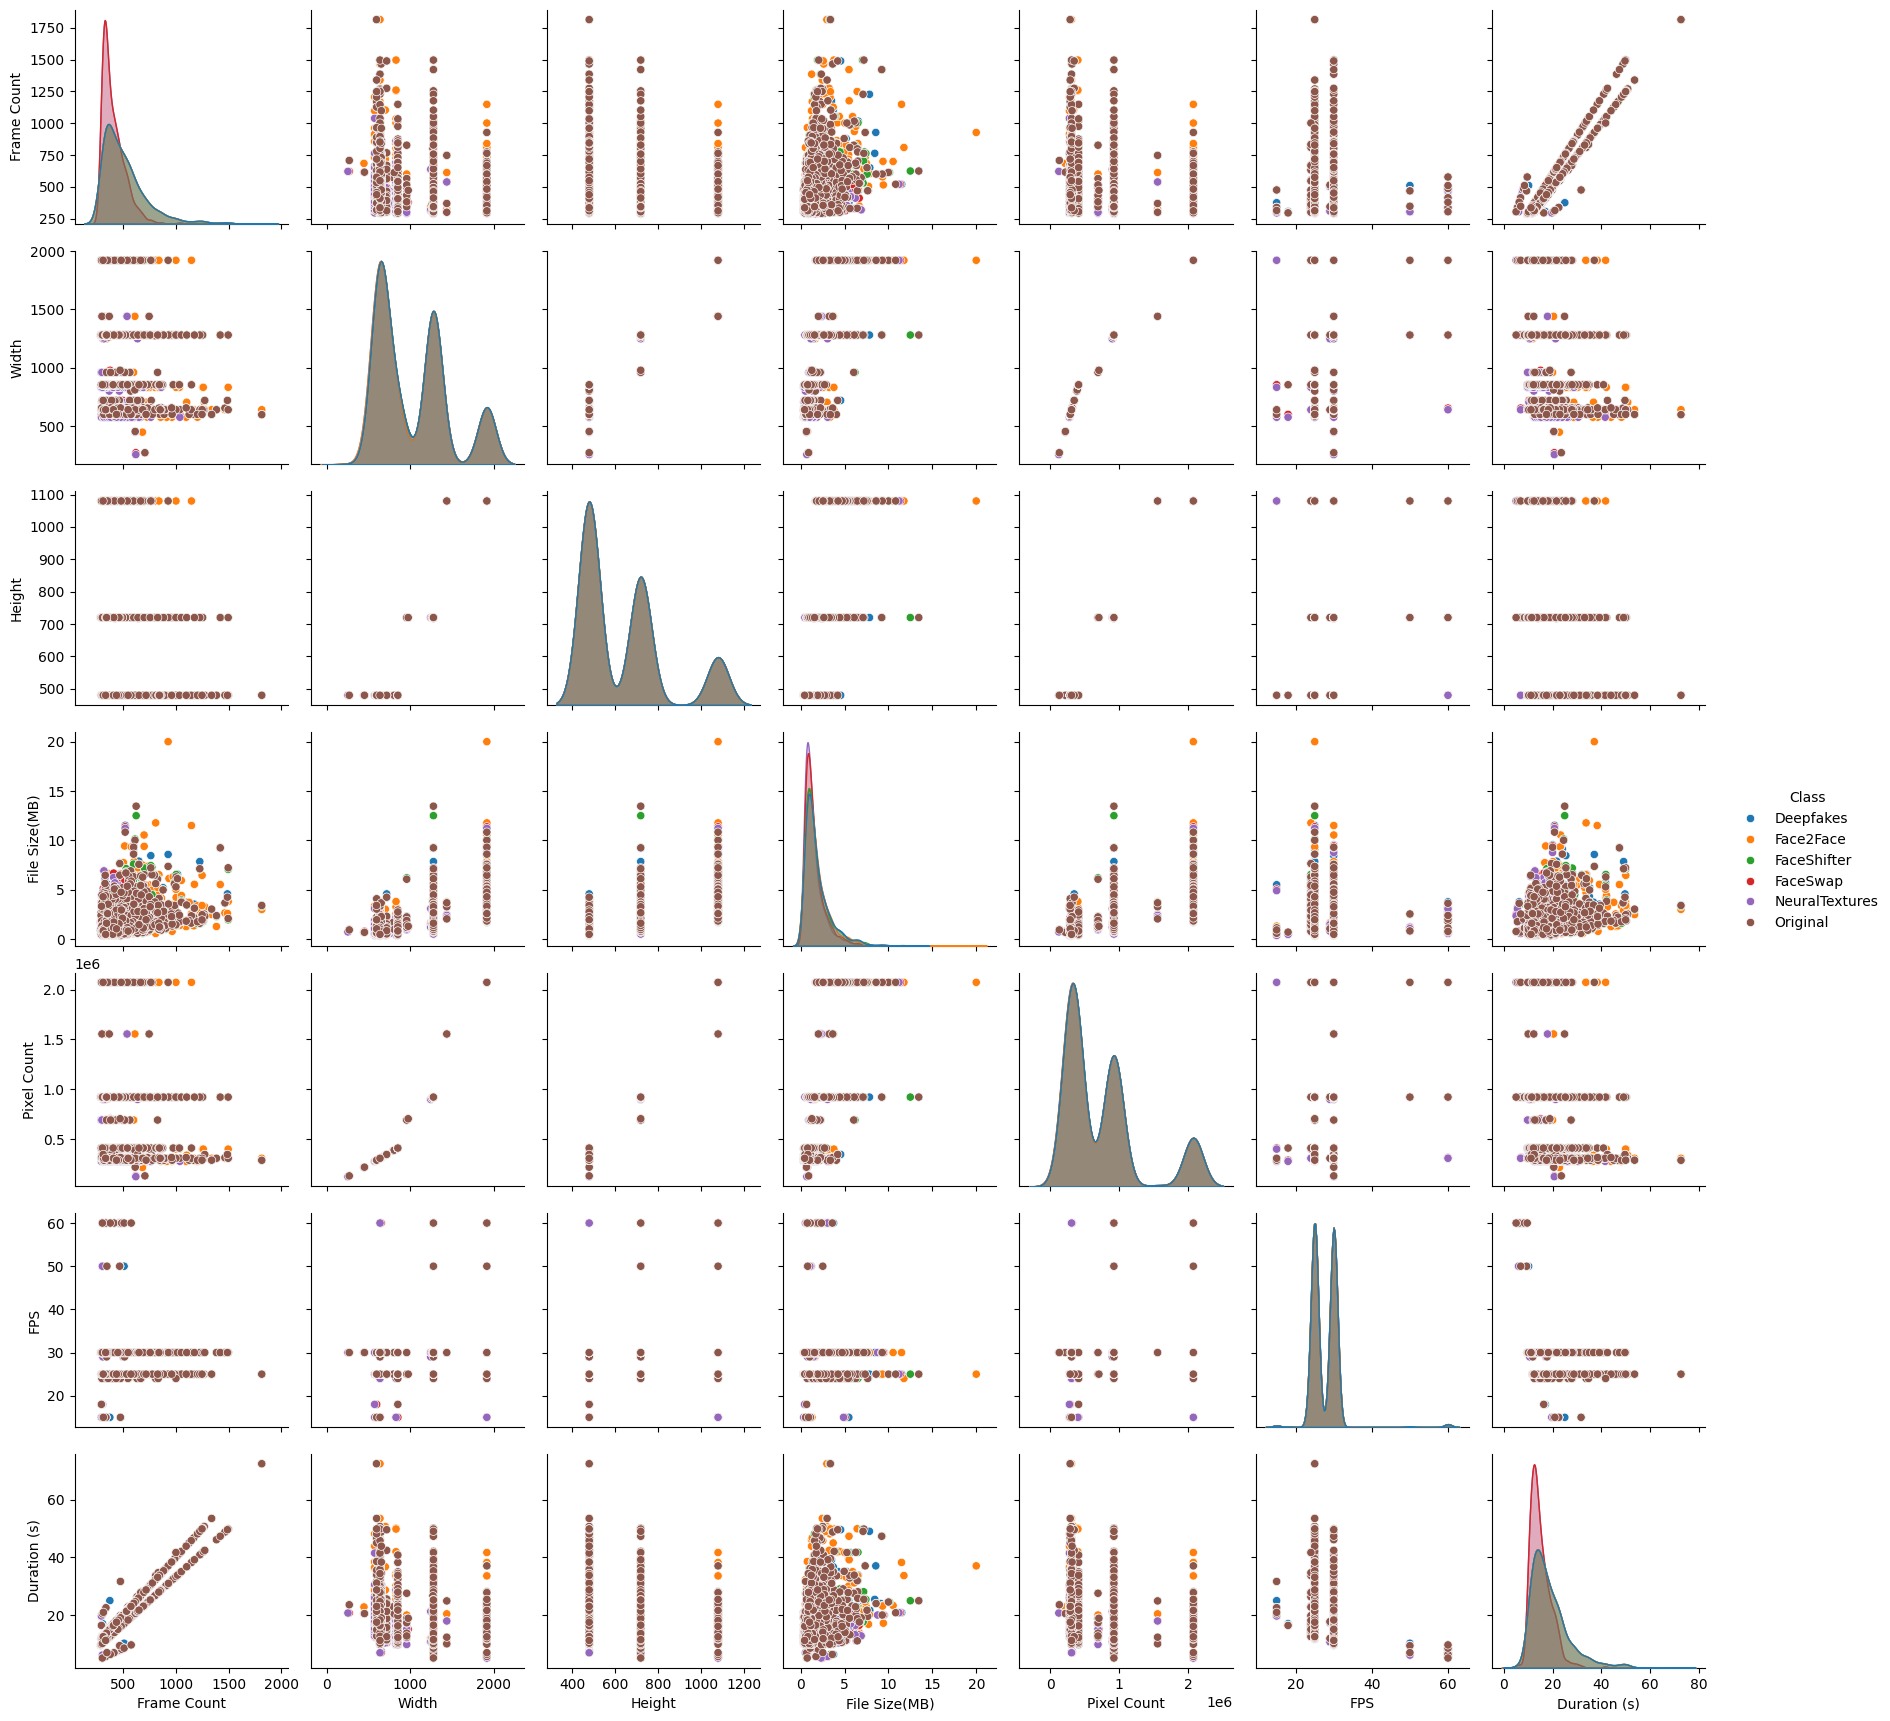

In [96]:
sns.pairplot(df[["Frame Count", "Width", "Height", "File Size(MB)", "Pixel Count", "FPS", "Duration (s)", "Class"]], hue="Class")
plt.show()

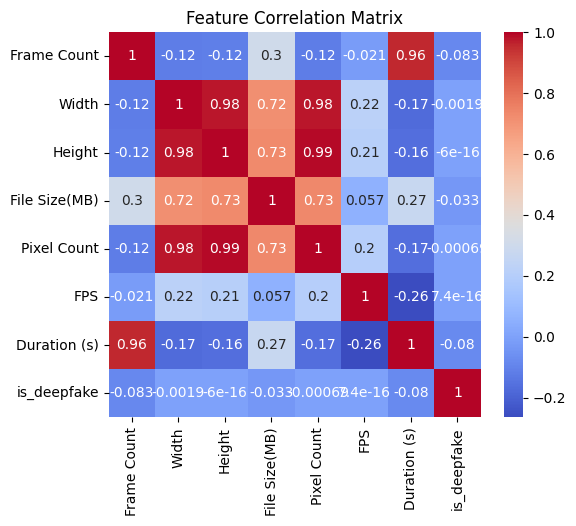

In [31]:
corr = df[["Frame Count", "Width", "Height", "File Size(MB)", "Pixel Count", "FPS", "Duration (s)", "is_deepfake"]].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

### Examples

In [25]:
def get_video_family(source_id):

    family = {"Original": DATASET_PATH / "original" / f"{source_id}.mp4"}
    fake_classes = [c for c in CLASSES if c != "Original"]

    for class_name in fake_classes:

        candidates = sorted((DATASET_PATH / class_name).glob(f"{source_id}_*.mp4"))

        if len(candidates) == 0:
            continue

        family[class_name] = candidates[0]

    return family

get_video_family("000")

{'Original': WindowsPath('c:/Users/tomma/DeepfakeSII/datasets/faceforensics++/original/000.mp4'),
 'Deepfakes': WindowsPath('c:/Users/tomma/DeepfakeSII/datasets/faceforensics++/Deepfakes/000_003.mp4'),
 'Face2Face': WindowsPath('c:/Users/tomma/DeepfakeSII/datasets/faceforensics++/Face2Face/000_003.mp4'),
 'FaceShifter': WindowsPath('c:/Users/tomma/DeepfakeSII/datasets/faceforensics++/FaceShifter/000_003.mp4'),
 'FaceSwap': WindowsPath('c:/Users/tomma/DeepfakeSII/datasets/faceforensics++/FaceSwap/000_003.mp4'),
 'NeuralTextures': WindowsPath('c:/Users/tomma/DeepfakeSII/datasets/faceforensics++/NeuralTextures/000_003.mp4')}

#### Show all versions of a frame

In [26]:
def show_frame_family(source_id, frame_number=0, random_sample=True):

    family = get_video_family(source_id)

    frames = []

    for name, path in family.items():

        cap = cv2.VideoCapture(str(path))
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_number) # open video
        ret, frame = cap.read() # read specified frame
        cap.release()

        if not ret: continue

        frame = cv2.resize(frame, (320, 180))
        cv2.putText(frame, name, (10, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
        frames.append(frame)

    top = np.hstack(frames[:3])
    bottom = np.hstack(frames[3:])
    grid = np.vstack([top, bottom])

    plt.figure(figsize=(15, 8))
    plt.imshow(cv2.cvtColor(grid, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()

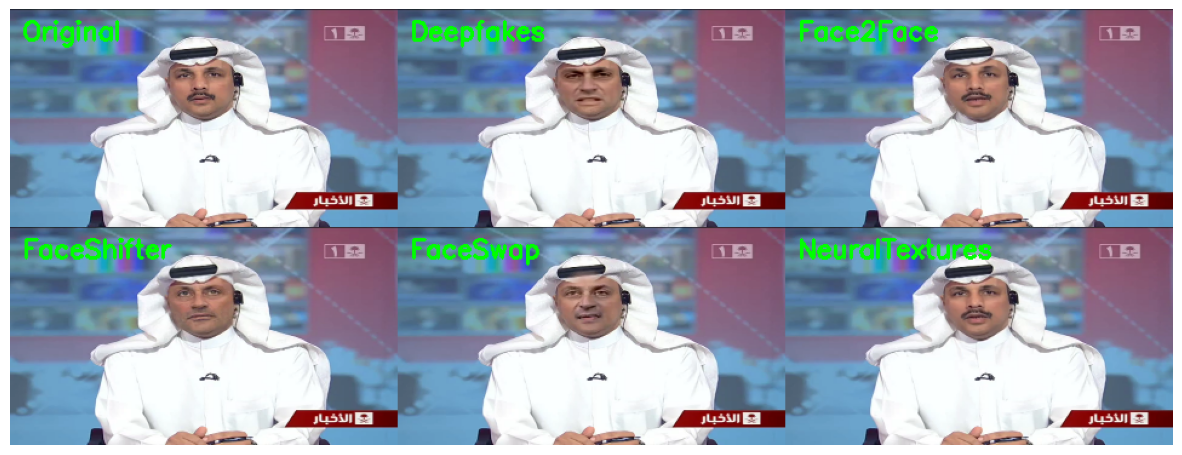

In [288]:
show_frame_family("000", frame_number=0)

#### Show all versions of a video

In [21]:
def save_video_family(source_id, output_file="comparison.mp4", fps=30):

    family = get_video_family(source_id)

    caps = {}

    for name, path in family.items():
        caps[name] = cv2.VideoCapture(str(path))

    cell_w = 320
    cell_h = 180

    writer = cv2.VideoWriter(output_file, cv2.VideoWriter_fourcc(*"mp4v"), fps, (cell_w * 3, cell_h * 2))

    while True:

        frames = []

        for name, cap in caps.items():

            ret, frame = cap.read()

            if not ret:

                writer.release()

                for c in caps.values():
                    c.release()

                print(f"Saved: {output_file}")
                return

            frame = cv2.resize(frame, (cell_w, cell_h))
            cv2.putText(frame, name, (10, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,255,0), 2)

            frames.append(frame)

        top = np.hstack(frames[:3])
        bottom = np.hstack(frames[3:])
        grid = np.vstack([top, bottom])

        writer.write(grid)

In [291]:
save_video_family("000", output_file="comparison_000.mp4", fps=30)

Saved: comparison_022.mp4


#### Show frames of one video sample

In [23]:
def show_video_samples(source_id, class_name, seconds=1):

    family = get_video_family(source_id)

    path = family[class_name]

    fps = df.loc[
        df["Video"] == path.stem,
        "FPS"
    ].iloc[0]

    cap = cv2.VideoCapture(str(path))

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    step = int(fps * seconds)

    frames = []

    for frame_number in range(0, total_frames, step):

        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_number) # move to desired frame

        ret, frame = cap.read() # read frame

        if not ret: continue

        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        cv2.putText(
            frame,
            f"{frame_number / fps:.1f}s",
            (10, 25),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (0, 255, 0),
            2
        )

        frames.append(frame)

    cap.release()

    cols = 4
    rows = int(np.ceil(len(frames) / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))

    axes = np.array(axes).reshape(-1)

    for ax, frame in zip(axes, frames):

        ax.imshow(frame)
        ax.axis("off")

    for ax in axes[len(frames):]:

        ax.axis("off")

    plt.suptitle(f"{class_name} ({fps:.0f} FPS)")
    plt.tight_layout()
    plt.show()

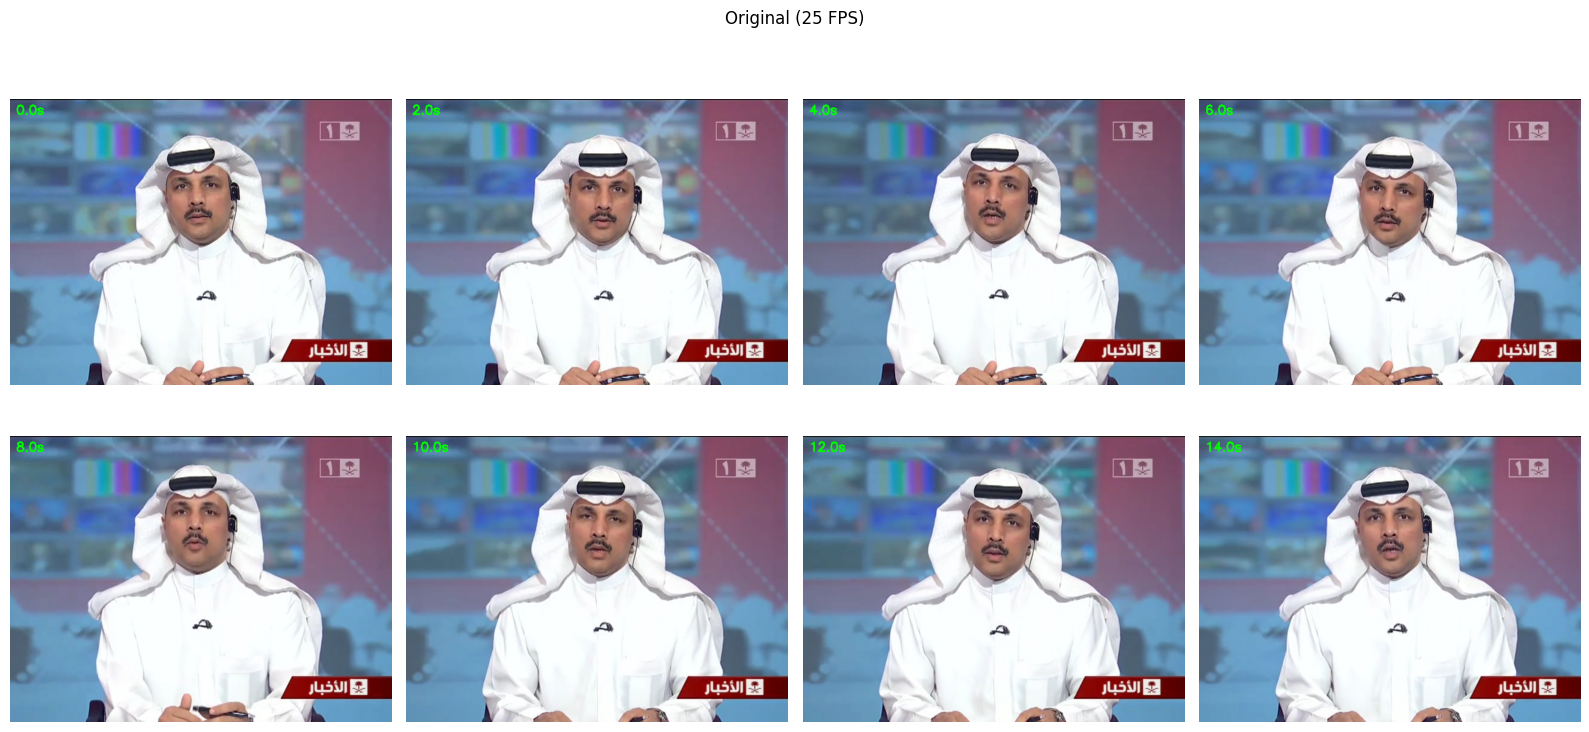

In [338]:
show_video_samples("000", "Original", seconds=2)

#### Show frames of one video sample, but cropping the face

Since Haar Cascade detected a face in 99.61% of sampled frames from the original FaceForensics++ videos, we used it as the face extraction method for both visualization and dataset preparation.

In [27]:
def show_face_samples(source_id, class_name, seconds=1):

    family = get_video_family(source_id)
    path = family[class_name]

    fps = df.loc[df["Video"] == path.stem, "FPS"].iloc[0] # fps of the video
    cap = cv2.VideoCapture(str(path))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) # number of frames of the video
    step = int(fps * seconds) # how often to sample frames

    detector = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")

    faces = []

    for frame_number in range(0, total_frames, step):

        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_number) # move to desired frame
        ret, frame = cap.read() # read frame
        if not ret: continue

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY) # convert to grayscale
        detections = detector.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5) # detect faces

        if len(detections) == 0: continue

        x, y, w, h = max(detections, key=lambda face: face[2] * face[3]) # largest face

        size = int(max(w, h) * 1.3) # enlarge bounding box by 30%

        center_x = x + w // 2
        center_y = y + h // 2

        x = max(center_x - size // 2, 0)
        y = max(center_y - size // 2, 0)

        size = min(size, frame.shape[1] - x, frame.shape[0] - y) # keep crop inside image
        crop = frame[y:y+size, x:x+size] # crop face region

        crop = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
        cv2.putText(crop, f"{frame_number / fps:.1f}s", (10, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,255,0), 2)

        faces.append(crop) # add face to faces list

    cap.release()

    cols = 4
    rows = int(np.ceil(len(faces) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
    axes = np.array(axes).reshape(-1)

    for ax, face in zip(axes, faces):

        ax.imshow(face)
        ax.axis("off")

    for ax in axes[len(faces):]:

        ax.axis("off")

    plt.suptitle(f"{class_name} Faces ({fps:.0f} FPS)")
    plt.tight_layout()
    plt.show()

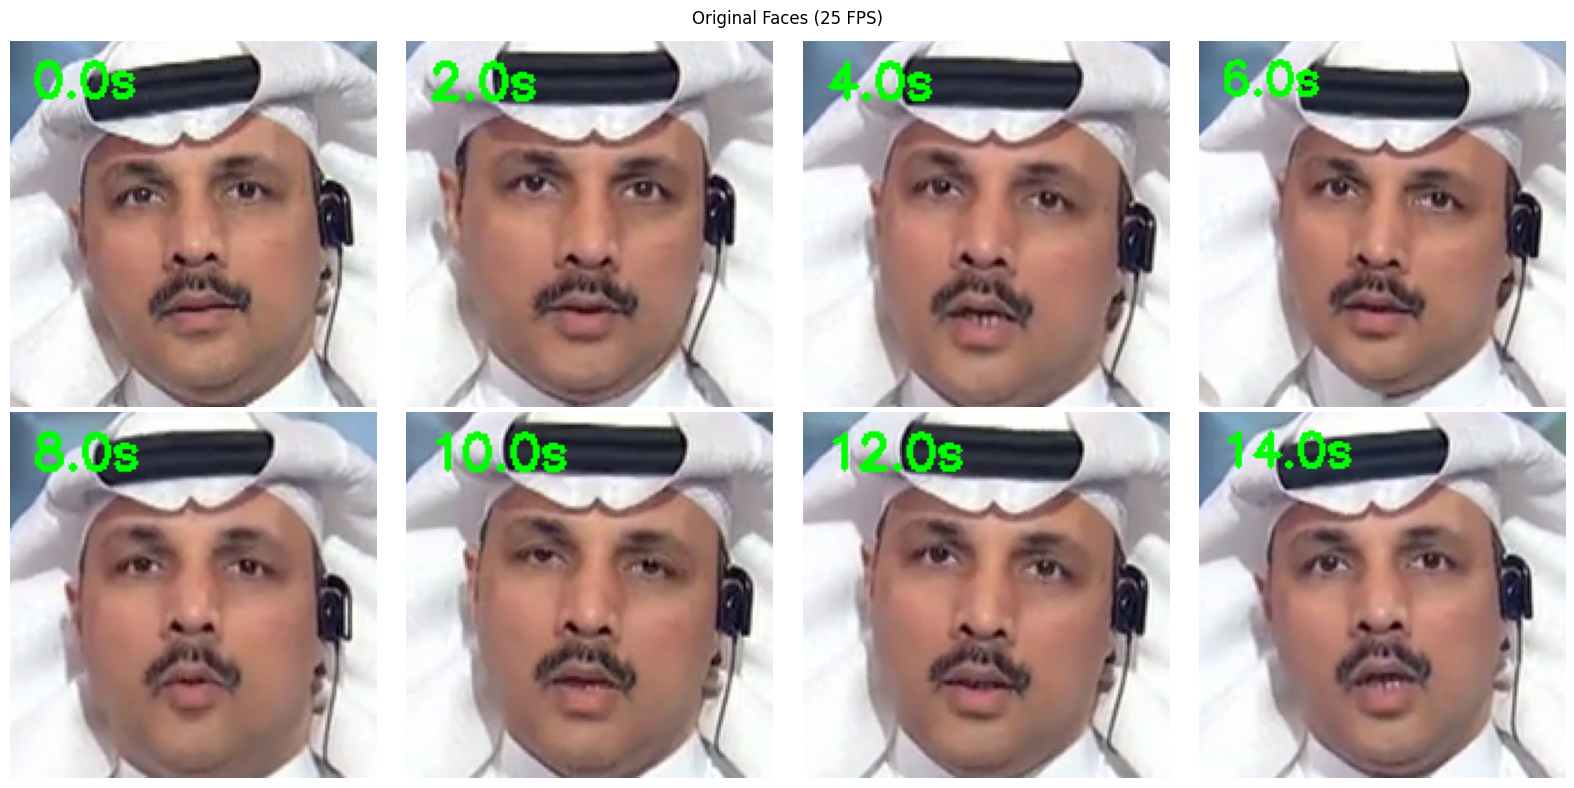

In [32]:
show_face_samples("000", "Original", seconds=2)

### RGB mean/std

In [72]:
def compute_rgb_stats_haar(seconds=2, padding=1.3, sample_size=100, seed=22):

    random.seed(seed)

    detector = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")

    rows = []

    sample_per_class = sample_size // len(CLASSES)

    for class_name in CLASSES:

        class_df = df[df["Class"] == class_name]
        n = min(sample_per_class, len(class_df))
        class_df = class_df.sample(n=n, random_state=seed)

        pixels_r = []
        pixels_g = []
        pixels_b = []

        for _, row in tqdm(class_df.iterrows(), total=len(class_df), desc=class_name):  # for each video

            path = DATASET_PATH / row["File Path"]
            fps = row["FPS"]

            cap = cv2.VideoCapture(str(path))

            total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
            step = int(fps * seconds) # how often to sample frames

            for frame_number in range(0, total_frames, step): # for each sampled frame

                cap.set(cv2.CAP_PROP_POS_FRAMES, frame_number) # move to desired frame
                ret, frame = cap.read()
                if not ret: continue

                gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY) # grayscale
                detections = detector.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5) # detect faces
                if len(detections) == 0: continue

                x, y, w, h = max(detections, key=lambda face: face[2] * face[3]) # largest face
                size = int(max(w, h) * padding) # enlarge bounding box by 30%

                center_x = x + w // 2
                center_y = y + h // 2

                x = max(center_x - size // 2, 0)
                y = max(center_y - size // 2, 0)

                size = min(size, frame.shape[1] - x, frame.shape[0] - y)

                crop = frame[y:y+size, x:x+size]

                crop = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)

                pixels_r.extend(crop[:, :, 0].reshape(-1))
                pixels_g.extend(crop[:, :, 1].reshape(-1))
                pixels_b.extend(crop[:, :, 2].reshape(-1))

            cap.release()

        rows.append({
            "Class": class_name,
            "R mean ± std": f"{np.mean(pixels_r):.2f} ± {np.std(pixels_r):.2f}",
            "G mean ± std": f"{np.mean(pixels_g):.2f} ± {np.std(pixels_g):.2f}",
            "B mean ± std": f"{np.mean(pixels_b):.2f} ± {np.std(pixels_b):.2f}"
        })

    rgb_df = pd.DataFrame(rows)

    return rgb_df

In [73]:
rgb_df = compute_rgb_stats_haar(seconds=2, padding=1.3, sample_size=600)

display(rgb_df)

Original:   0%|          | 0/100 [00:00<?, ?it/s]

Deepfakes:   0%|          | 0/100 [00:00<?, ?it/s]

Face2Face:   0%|          | 0/100 [00:00<?, ?it/s]

FaceShifter:   0%|          | 0/100 [00:00<?, ?it/s]

FaceSwap:   0%|          | 0/100 [00:00<?, ?it/s]

NeuralTextures:   0%|          | 0/100 [00:00<?, ?it/s]

,Class,R mean ± std,G mean ± std,B mean ± std
0,Original,139.39 ± 69.34,111.39 ± 59.55,102.23 ± 58.06
1,Deepfakes,139.49 ± 68.80,111.49 ± 59.08,102.56 ± 57.87
2,Face2Face,137.52 ± 68.63,110.60 ± 59.51,103.10 ± 59.47
3,FaceShifter,137.36 ± 68.71,109.83 ± 59.34,100.73 ± 57.66
4,FaceSwap,137.42 ± 68.22,110.23 ± 58.63,102.36 ± 57.99
5,NeuralTextures,137.68 ± 69.35,109.58 ± 59.45,101.67 ± 58.69


### Face statistics

In [74]:
def compute_face_stats_haar(seconds=2, sample_size=1000, seed=22):

    random.seed(seed)

    detector = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")

    rows = []

    sample_per_class = sample_size // len(CLASSES)

    for class_name in CLASSES:

        class_df = df[df["Class"] == class_name]
        n = min(sample_per_class, len(class_df))
        class_df = class_df.sample(n=n, random_state=seed)

        for _, row in tqdm(class_df.iterrows(), total=len(class_df), desc=class_name, leave=False):

            path = DATASET_PATH / row["File Path"]
            fps = row["FPS"]

            cap = cv2.VideoCapture(str(path))

            total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
            step = int(fps * seconds)

            for frame_number in range(0, total_frames, step):

                cap.set(cv2.CAP_PROP_POS_FRAMES, frame_number)
                ret, frame = cap.read()
                if not ret: continue

                H, W = frame.shape[:2]

                gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

                faces = detector.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)

                if len(faces) == 0: continue

                x, y, w, h = max(faces, key=lambda face: face[2] * face[3])

                rows.append({
                    "Class": class_name,
                    "center_x": (x + w / 2) / W,
                    "center_y": (y + h / 2) / H,
                    "bbox_width": w / W,
                    "bbox_height": h / H,
                    "face_area_ratio": (w * h) / (W * H)
                })

            cap.release()

    stats_df = pd.DataFrame(rows)

    return stats_df

In [75]:
face_df = compute_face_stats_haar(seconds=2, sample_size=600)

Original:   0%|          | 0/100 [00:00<?, ?it/s]

Deepfakes:   0%|          | 0/100 [00:00<?, ?it/s]

Face2Face:   0%|          | 0/100 [00:00<?, ?it/s]

FaceShifter:   0%|          | 0/100 [00:00<?, ?it/s]

FaceSwap:   0%|          | 0/100 [00:00<?, ?it/s]

NeuralTextures:   0%|          | 0/100 [00:00<?, ?it/s]

C:\Users\tomma\AppData\Local\Temp\ipykernel_44284\2973045205.py:18: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


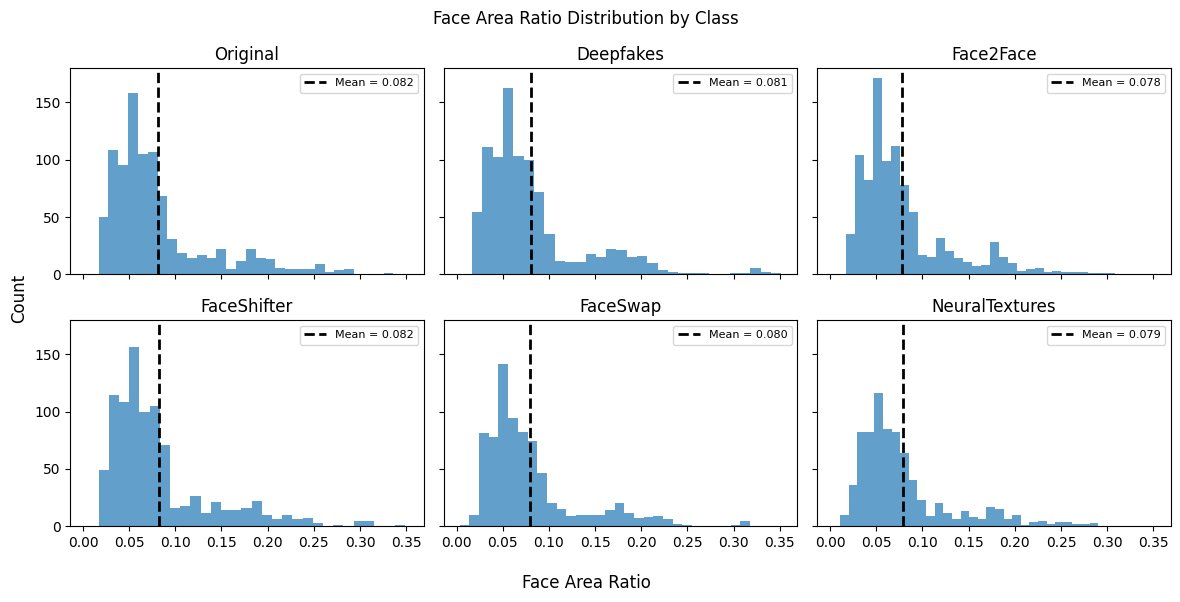

In [76]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6), sharex=True, sharey=True)
axes = axes.flatten()

for ax, class_name in zip(axes, CLASSES):

    ratios = face_df[face_df["Class"] == class_name]["face_area_ratio"]
    mean_ratio = ratios.mean()

    ax.hist(ratios, bins=30, alpha=0.7)
    ax.axvline(mean_ratio, color="black", linestyle="--", linewidth=2, label=f"Mean = {mean_ratio:.3f}")
    ax.set_title(class_name)
    ax.legend(fontsize=8)

fig.supxlabel("Face Area Ratio")
fig.supylabel("Count")

plt.suptitle("Face Area Ratio Distribution by Class")
plt.tight_layout()
plt.show()

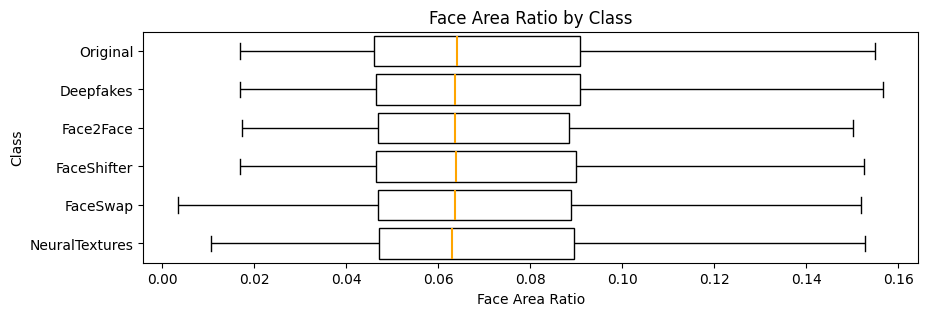

In [77]:
plt.figure(figsize=(10,3))

sns.boxplot(data=face_df, x="face_area_ratio", y="Class", order=CLASSES, showfliers=False,
    boxprops={"facecolor": "white", "edgecolor": "black"},
    medianprops={"color": "orange", "linewidth": 1.5},
    whiskerprops={"color": "black"},
    capprops={"color": "black"}
)

plt.title("Face Area Ratio by Class")
plt.xlabel("Face Area Ratio")

plt.show()

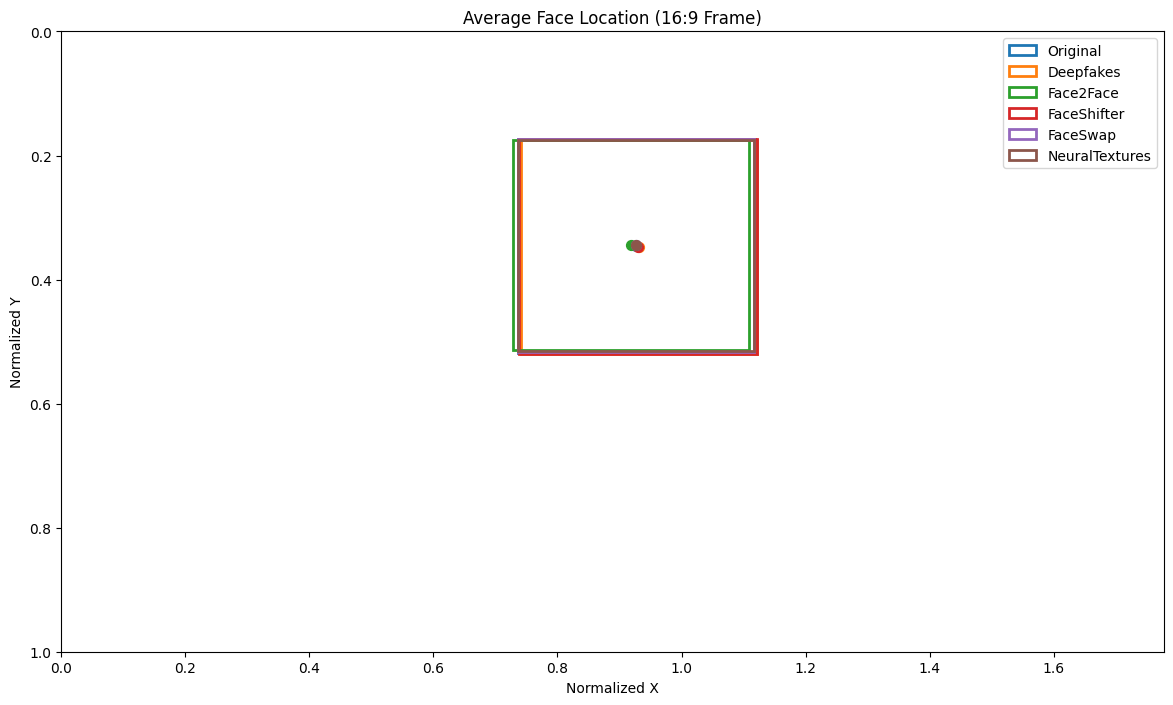

In [78]:
fig, ax = plt.subplots(figsize=(12, 7))
aspect_ratio = 16 / 9
colors = plt.cm.tab10.colors

for color, class_name in zip(colors, CLASSES):

    class_df = face_df[face_df["Class"] == class_name]

    mean_x = class_df["center_x"].mean()
    mean_y = class_df["center_y"].mean()

    mean_w = class_df["bbox_width"].mean()
    mean_h = class_df["bbox_height"].mean()

    mean_x = mean_x * aspect_ratio
    mean_w = mean_w * aspect_ratio

    rect = plt.Rectangle((mean_x - mean_w / 2, mean_y - mean_h / 2), mean_w, mean_h, fill=False, linewidth=2, edgecolor=color, label=class_name)

    ax.add_patch(rect)
    ax.scatter(mean_x, mean_y, color=color, s=50)

ax.set_xlim(0, aspect_ratio)
ax.set_ylim(1, 0)

ax.set_aspect("equal")

ax.set_title("Average Face Location (16:9 Frame)")

ax.set_xlabel("Normalized X")
ax.set_ylabel("Normalized Y")

ax.legend()

plt.tight_layout()
plt.show()

In [79]:
summary_global = (
    face_df
    .groupby("Class")
    .agg(
        center_x_mean=("center_x", "mean"),
        center_y_mean=("center_y", "mean"),
        face_ratio_mean=("face_area_ratio", "mean"),
        face_ratio_std=("face_area_ratio", "std")
    )
    .round(4)
)

print(summary_global)

                center_x_mean  center_y_mean  face_ratio_mean  face_ratio_std
Class                                                                        
Deepfakes              0.5243         0.3473           0.0808          0.0549
Face2Face              0.5168         0.3446           0.0783          0.0497
FaceShifter            0.5228         0.3468           0.0822          0.0564
FaceSwap               0.5214         0.3449           0.0798          0.0520
NeuralTextures         0.5211         0.3449           0.0793          0.0524
Original               0.5215         0.3461           0.0817          0.0563


### Frequency

In [80]:
def extract_frequency_features_haar(seconds=2, padding=1.3, sample_size=600, image_size=224, seed=22):

    random.seed(seed)

    detector = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")

    spectra = {}
    profiles = {}

    sample_per_class = sample_size // len(CLASSES)

    for class_name in CLASSES:

        class_df = df[df["Class"] == class_name]

        n = min(sample_per_class, len(class_df))

        class_df = class_df.sample(n=n, random_state=seed)

        spectra[class_name] = []
        profiles[class_name] = []

        for _, row in tqdm(class_df.iterrows(), total=len(class_df), desc=class_name):

            path = DATASET_PATH / row["File Path"]
            fps = row["FPS"]

            cap = cv2.VideoCapture(str(path))

            total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
            step = int(fps * seconds)

            for frame_number in range(0, total_frames, step):

                cap.set(cv2.CAP_PROP_POS_FRAMES, frame_number)
                ret, frame = cap.read()
                if not ret: continue

                gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
                faces = detector.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)
                if len(faces) == 0: continue

                x, y, w, h = max(faces, key=lambda face: face[2] * face[3])
                size = int(max(w, h) * padding)

                center_x = x + w // 2
                center_y = y + h // 2

                x = max(center_x - size // 2, 0)
                y = max(center_y - size // 2, 0)

                size = min(size, frame.shape[1] - x, frame.shape[0] - y)

                crop = gray[y:y+size, x:x+size]
                crop = cv2.resize(crop, (image_size, image_size))

                fft = np.fft.fft2(crop) # 2D Fourier Transform
                fft = np.fft.fftshift(fft) # shift zero frequency to center

                spectrum = np.log(np.abs(fft) + 1) # compute log magnitude spectrum

                spectra[class_name].append(spectrum)

                # radial profile
                H, W = spectrum.shape

                cx = W // 2
                cy = H // 2

                yy, xx = np.indices(spectrum.shape)

                radius = np.sqrt((xx - cx) ** 2 + (yy - cy) ** 2).astype(int) # compute mean spectrum value for each ring (radius)
                profile = np.bincount(radius.ravel(), weights=spectrum.ravel()) / np.bincount(radius.ravel())

                profiles[class_name].append(profile)

            cap.release()

        # average over all samples for each class
        spectra[class_name] = np.mean(spectra[class_name], axis=0)
        min_len = min(len(profile) for profile in profiles[class_name])
        trimmed_profiles = []

        for profile in profiles[class_name]:
            trimmed_profiles.append(profile[:min_len])

        profiles[class_name] = np.mean(trimmed_profiles, axis=0)

    return spectra, profiles

In [81]:
spectra, profiles = extract_frequency_features_haar(
    seconds=2,
    padding=1.3,
    sample_size=600,
    image_size=224,
    seed=22
)

Original:   0%|          | 0/100 [00:00<?, ?it/s]

Deepfakes:   0%|          | 0/100 [00:00<?, ?it/s]

Face2Face:   0%|          | 0/100 [00:00<?, ?it/s]

FaceShifter:   0%|          | 0/100 [00:00<?, ?it/s]

FaceSwap:   0%|          | 0/100 [00:00<?, ?it/s]

NeuralTextures:   0%|          | 0/100 [00:00<?, ?it/s]

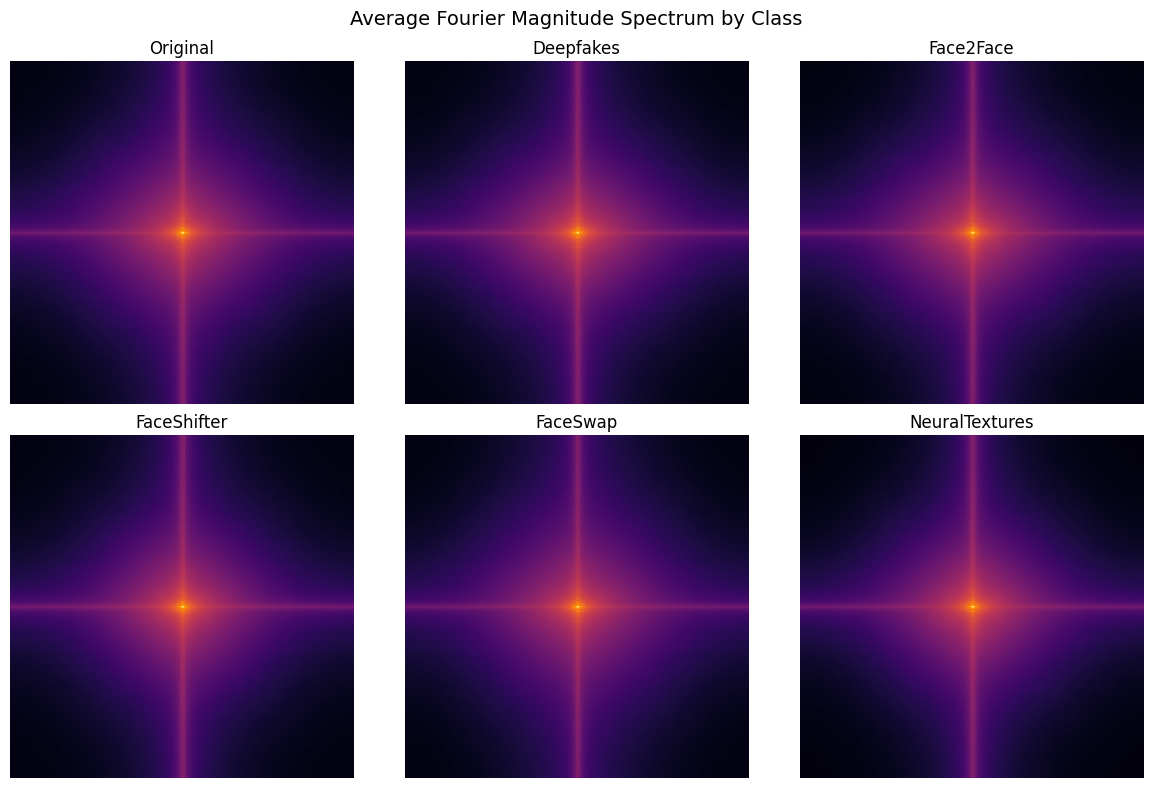

In [83]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for ax, class_name in zip(axes, CLASSES):
    ax.imshow(spectra[class_name], cmap="inferno")
    ax.set_title(class_name)
    ax.axis("off")

fig.suptitle("Average Fourier Magnitude Spectrum by Class", fontsize=14)
plt.tight_layout()
plt.show()

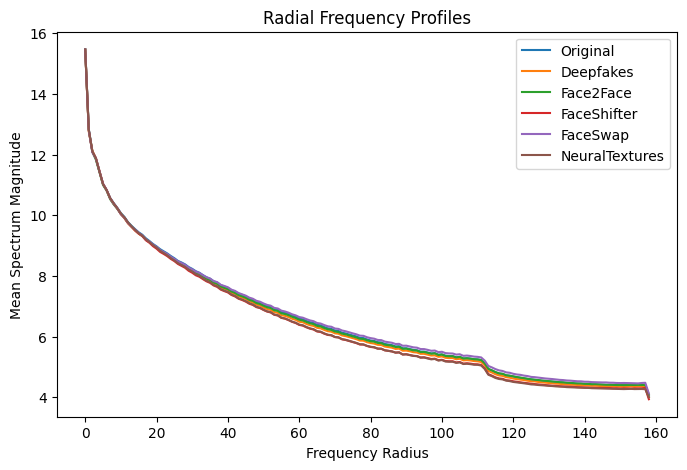

In [85]:
plt.figure(figsize=(8,5))

for class_name in CLASSES:

    plt.plot(
        profiles[class_name],
        label=class_name
    )

plt.xlabel("Frequency Radius")

plt.ylabel("Mean Spectrum Magnitude")

plt.title(
    "Radial Frequency Profiles"
)

plt.legend()

plt.show()

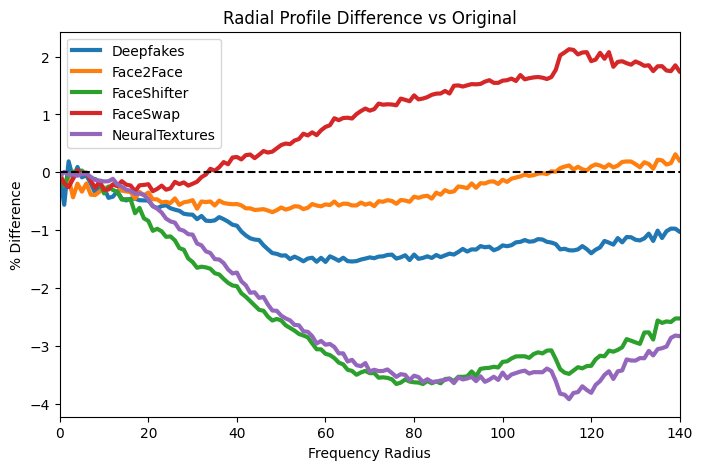

In [88]:
plt.figure(figsize=(8,5))

for class_name in CLASSES:
    if class_name == "Original": continue
    difference_percent = (profiles[class_name] - profiles["Original"]) / profiles["Original"] * 100
    plt.plot(difference_percent, linewidth=3, label=class_name)

plt.axhline(0, color="black", linestyle="--")
plt.xlim(0, 140)
plt.xlabel("Frequency Radius")
plt.ylabel("% Difference")
plt.title("Radial Profile Difference vs Original")
plt.legend()
plt.show()